## 🔷 What is Logistic Regression?

Despite the name, Logistic Regression is a classification algorithm, not regression.

#### 👉 It is used to predict probability of a class (mostly binary: 0 or 1)

**Examples:**

* Spam (1) or Not Spam (0)
* Pass / Fail
* Disease / No Disease
### 🧠 Core Idea (Intuition First)
**Problem with Linear Regression:**

* If we use linear regression for classification:
$$
y=wx+b
$$

**👉 Output can be:**

* less than 0 ❌
* greater than 1 ❌

### But probabilities must be between 0 and 1

**🔥 Solution: Sigmoid Function**

* Logistic regression applies a sigmoid (S-shaped) function to convert output into probability:

$$ 
\sigma(z) = \frac{1}{1/1+e^{-z}}
$$



**👉 Where:**

$$
Z = wx+b
$$


### 📈 What Sigmoid Does:
* Converts any value → between 0 and 1
* Large positive → close to 1
* Large negative → close to 0
## 🎯 Final Model

$$
\hat{y} = \sigma(wx + b)
$$

**👉 Output = probability**

> Then:

* If ≥ 0.5 → Class 1
* If < 0.5 → Class 0
### 📊 Decision Boundary

**Even though sigmoid is curved, the decision boundary is:**

$$
wx+b=0
$$
**👉 This is a straight line (or plane)**

### ❗ Why Not Use MSE?

**If we use MSE (like linear regression):**

* Loss becomes non-convex
* Optimization becomes hard
## ✅ Instead: Log Loss (Cross-Entropy)
$$
-\frac{1}{n} \sum_{i=1}^{n} \left[ y_i \log(\hat{y}_i) + (1 - y_i)\log(1 - \hat{y}_i) \right]
$$

#### 👉 Why this works:

* Penalizes wrong predictions heavily
* Convex → easy to optimize
###v ⚙️ How It Learns

**Uses:**

* Gradient Descent

**Steps:**

* Start with random weights
* Predict probabilities
* Calculate loss
* Update weights
* Repeat
### 📌 Where is Logistic Regression Used?
1. 🧾 Classification Problems
Email spam detection
Fraud detection
Disease prediction
2. 🏦 Finance
Credit risk prediction
Loan approval
3. 🏥 Healthcare
Cancer detection
Survival prediction
4. 📊 Marketing
Customer churn prediction
Ad click prediction
### 🔍 Types of Logistic Regression
* Type	Description
* Binary	2 classes
* Multinomial	More than 2 classes
* Ordinal	Ordered classes
### ⚖️ Advantages

* ✅ Simple and fast
* ✅ Interpretable
* ✅ Works well for linearly separable data
* ✅ Outputs probability

### ⚠️ Limitations

* ❌ Cannot handle complex non-linear data
* ❌ Sensitive to outliers
* ❌ Needs feature scaling


### 🧠 Deep Intuition (Very Important)

**Think like this:**

***👉 Linear Regression:***

* Predicts continuous values

***👉 Logistic Regression:***

* Predicts probability → then class

***🔥 Real-Life Analogy***

### Imagine:

* Exam score → probability of passing

* If score increases:

* Probability gradually increases (not suddenly)

* 👉 That smooth transition = sigmoid curve

## 🎯 Interview Summary
* Logistic Regression = classification algorithm
* Uses sigmoid function
* Outputs probability
* Uses log loss
* Decision boundary is linear


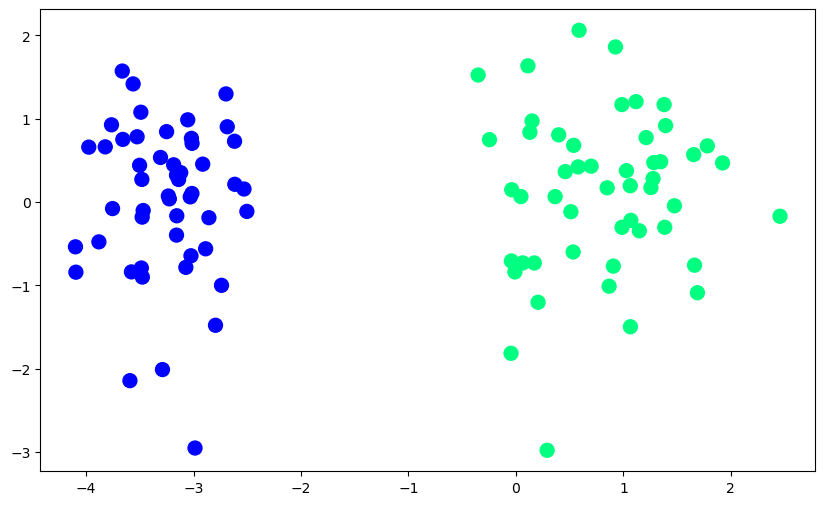

[[2.36679363 0.02300492]]
[3.13571596]


In [91]:
from sklearn.datasets import make_classification
import numpy as np

X , y = make_classification(n_samples = 100,n_features=2,n_informative=1,n_redundant=0,
                            n_classes=2,n_clusters_per_class=1,
                            random_state=41,hypercube=False,class_sep=20)
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.scatter(X[:,0],X[:,1],c = y,cmap='winter',s = 100)
plt.show()


from sklearn.linear_model import LogisticRegression
lor = LogisticRegression()
lor.fit(X,y)
print(lor.coef_)
print(lor.intercept_)
m = -(lor.coef_[0][0]/lor.coef_[0][1])
b = -(lor.intercept_/lor.coef_[0][1])
X_input = np.linspace(-3,3,100)
y_input = m*X_input+b



Coef:   [4.83926872 0.21182255]
intercept:   5.833388649053249


(-3.0, 2.0)

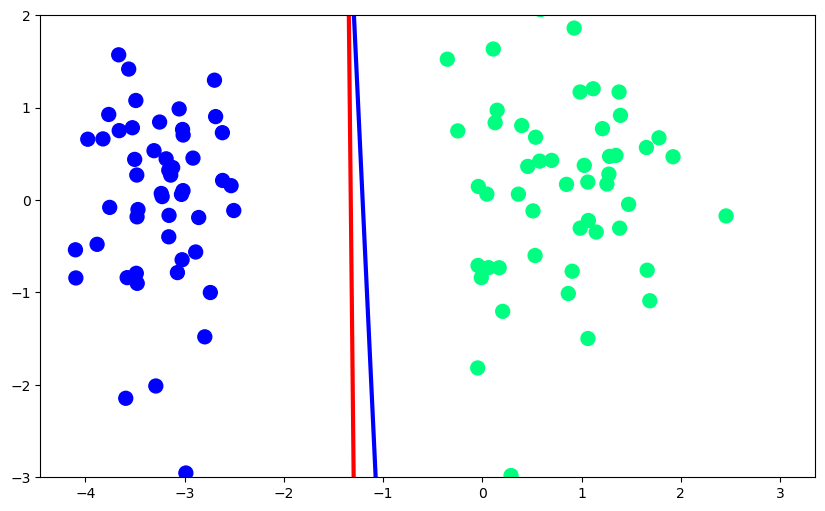

In [110]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def gd(X,y):
    lr = 0.5
    X = np.insert(X,0,1,axis = 1)
    weight = np.ones(X.shape[1])

    for i in range(5000):
        y_hat = sigmoid(np.dot(X,weight))
        weight = weight + lr*(np.dot((y-y_hat),X)/X.shape[0])

    return weight[1:],weight[0]

coef,intercept = gd(X,y)
print("Coef:  ",coef)
print("intercept:  ",intercept)

m1 = -(coef[0]/coef[1])
b1 = -(intercept/coef[1])

X_inp = np.linspace(-3,3,100)
y_inp = m1*X_inp+b1

plt.figure(figsize=(10,6))
plt.plot(X_input,y_input,color = 'r',linewidth = 3)
plt.plot(X_inp,y_inp,color = 'b',linewidth = 3)
plt.scatter(X[:,0],X[:,1],c=y,cmap="winter",s = 100)
plt.ylim(-3,2)